# Task 1: Data Preparation


In [1]:
# Start from here to write your code for Task 1. Please also feel free to add more cells in this ipynb file. 
#Loads the correct extentions needed  to run code for Task 1.
import pandas as pd
import numpy as np
import re

In [2]:
#1 Load csv into a data frame
df = pd.read_csv("victorian_road_crash_data.csv")

In [3]:
#Fixes the date and time columns to be in the correct format for easier analysis.
df['ACCIDENT_DATE'] = pd.to_datetime(df['ACCIDENT_DATE'], format='%d/%m/%Y', errors='coerce')
df['ACCIDENT_TIME'] = pd.to_datetime(df['ACCIDENT_TIME'], format='%H:%M:%S', errors='coerce').dt.time

In [4]:
#Fixing some of the missing data
# Will drop the SRNS column as it is missing a good portion of data
df = df.drop(columns=['SRNS']) 

#dropping rows with missing values in the specified columns as it is a small portion of data and not really needed if we have suburb
df = df.dropna(subset=['LATITUDE', 'LONGITUDE', 'NO_OF_VEHICLES', ])

#will fill the missing values with a unknown for caterogical data 
categorical_cols = ['ROAD_NAME', 'ROAD_TYPE', 'LGA_NAME', 'DTP_REGION', 
                    'DEG_URBAN_NAME', 'RMA', 'DIVIDED', 'STAT_DIV_NAME']
df[categorical_cols] = df[categorical_cols].fillna('Unknown')

In [5]:
#drops the non needed vicgrid due to having lat x long
df = df.drop(columns=['VICGRID_X', 'VICGRID_Y'], errors='ignore')

# we need to keep the lat and long so itll filted out junk ones
df = df.dropna(subset=['LATITUDE', 'LONGITUDE'])

In [6]:
#4 Cleans the Speed_Zone column and identifies if speed is either unknown or seen as a other.   Replaces the value with NaN
def clean_speed(val):
    if pd.isna(val):
        return np.nan
    val = str(val).lower()


    if 'not know' in val or 'other' in val: 
        return np.nan
    

# Uses normal experessions to extract the number before being put back in the cleaned 
    nums = re.findall(r'\d+', val)
    if nums:
        speed = int(nums[0])
     #Cleans anomalies like 10000 km/hr
        if speed > 110 or speed == 0:
            return np.nan
        return speed
    return np.nan


In [7]:
# List of columns that should be whole numbers, not decimals.
cols_to_fix = [
    'NO_OF_VEHICLES', 'HEAVYVEHICLE', 'PASSENGERVEHICLE', 
    'MOTORCYCLE', 'PT_VEHICLE'
]

# Convert them to integers
for col in cols_to_fix:
    df[col] = df[col].astype(int)

# Optional: You might want to do this for ROAD_ROUTE_1 too if you filled its NaNs
df['ROAD_ROUTE_1'] = df['ROAD_ROUTE_1'].fillna(0).astype(int)

In [8]:
# Create the column first
df['SPEED_ZONE_NUM'] = df['SPEED_ZONE'].apply(clean_speed)

# Use 'Int64' (Capital I) to allow whole numbers + NaNs
df['SPEED_ZONE_NUM'] = df['SPEED_ZONE_NUM'].astype('Int64')

# Int64 allows for ibts + NANS
cols_to_fix = ['SPEED_ZONE_NUM']
for col in cols_to_fix:
    df[col] = df[col].astype('Int64')

In [9]:
# Fixes the DEG_URBAN_NAME column to replace underscores with spaces for better readability.
df['DEG_URBAN_NAME'] = df['DEG_URBAN_NAME'].str.replace('_', ' ', regex=False)

# Fixes the vehicle count columns to be whole numbers (2.0 -> 2)
cols_to_fix = ['NO_OF_VEHICLES', 'HEAVYVEHICLE', 'PASSENGERVEHICLE', 'MOTORCYCLE', 'PT_VEHICLE']
for col in cols_to_fix:
    df[col] = df[col].astype(int)

In [10]:
# 5. diplays that it processed correctely and then displays the first few rows to show the changes
print(f"Data successfully cleaned. New shape: {df.shape}")
display(df.head())

Data successfully cleaned. New shape: (150395, 50)


,ACCIDENT_NO,ACCIDENT_DATE,ACCIDENT_TIME,ACCIDENT_TYPE,DAY_OF_WEEK,DCA_CODE,DCA_CODE_DESCRIPTION,LIGHT_CONDITION,POLICE_ATTEND,ROAD_GEOMETRY,...,NO_OF_VEHICLES,HEAVYVEHICLE,PASSENGERVEHICLE,MOTORCYCLE,PT_VEHICLE,DEG_URBAN_NAME,RMA,DIVIDED,STAT_DIV_NAME,SPEED_ZONE_NUM
0,T20150000784,2015-01-01,17:50:00,Collision with vehicle,Thursday,163,VEHICLE STRIKES DOOR OF PARKED/STATIONARY VEHICLE,Day,No,Not at intersection,...,2,0,1,0,0,MELB URBAN,Arterial Highway,Undivided,Metro,50
1,T20150000043,2015-01-01,19:30:00,No collision and no object struck,Thursday,184,OUT OF CONTROL ON CARRIAGEWAY (ON BEND),Dusk/Dawn,Yes,T intersection,...,1,0,0,1,0,RURAL VICTORIA,Arterial Other,Undivided,Metro,60
2,T20150000037,2015-01-01,19:00:00,Collision with vehicle,Thursday,110,CROSS TRAFFIC(INTERSECTIONS ONLY),Dusk/Dawn,Yes,Cross intersection,...,2,0,1,0,0,MELB URBAN,Arterial Other,Divided,Metro,60
3,T20150000008,2015-01-01,00:10:00,Collision with vehicle,Thursday,120,HEAD ON (NOT OVERTAKING),Dark No street lights,Yes,Not at intersection,...,2,0,0,2,0,RURAL VICTORIA,Unknown,Unknown,Country,100
4,T20150000050,2015-01-01,04:00:00,Struck Pedestrian,Thursday,109,ANY MANOEUVRE INVOLVING PED NOT INCLUDED IN DC...,Dark No street lights,Yes,Not at intersection,...,1,0,1,0,0,RURAL VICTORIA,Local Road,Undivided,Country,50


In [11]:
df.to_csv('cleaned.csv', index=False)

# Task 2: Data Exploration

## Task 2.1 

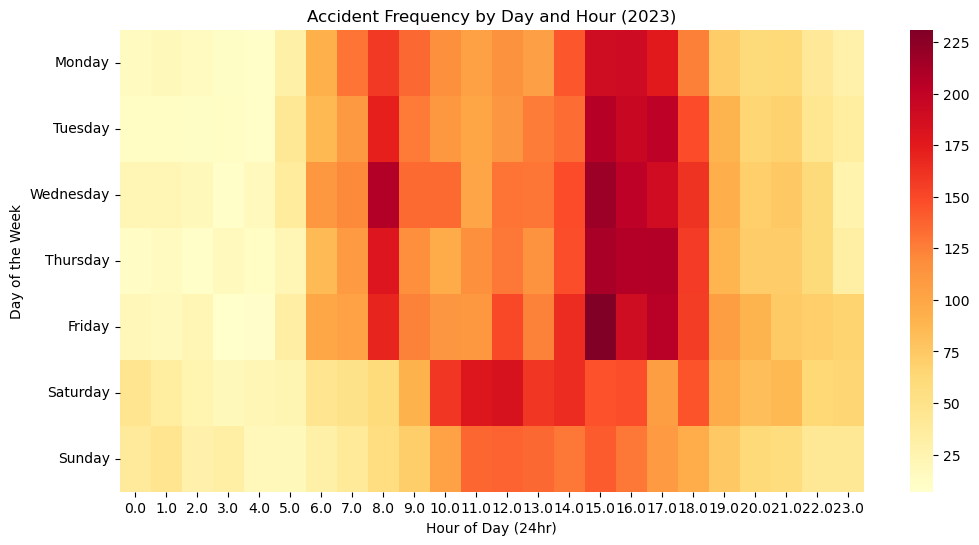

In [18]:
# Code goes after this line by adding cells
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Filter for 2023 and extract the Hour
df_2023 = df[df['ACCIDENT_DATE'].dt.year == 2023].copy()
df_2023['HOUR'] = pd.to_datetime(df_2023['ACCIDENT_TIME'], format='%H:%M:%S').dt.hour

# 2. Create a pivot table for the Heatmap
# We'll order the days correctly
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
heatmap_data = df_2023.groupby(['DAY_OF_WEEK', 'HOUR']).size().unstack().reindex(day_order)

# 3. Plotting
plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, cmap="YlOrRd", annot=False)
plt.title('Accident Frequency by Day and Hour (2023)')
plt.xlabel('Hour of Day (24hr)')
plt.ylabel('Day of the Week')
plt.show()

## Task 2.2 

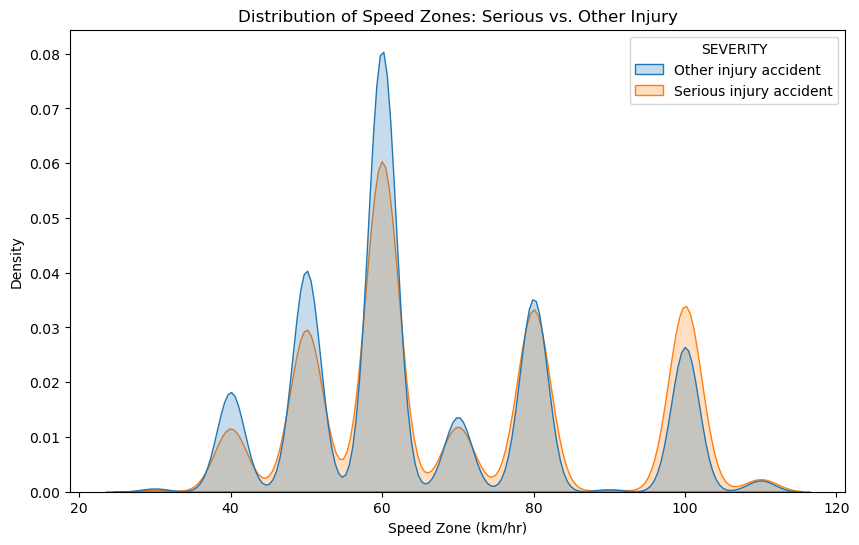

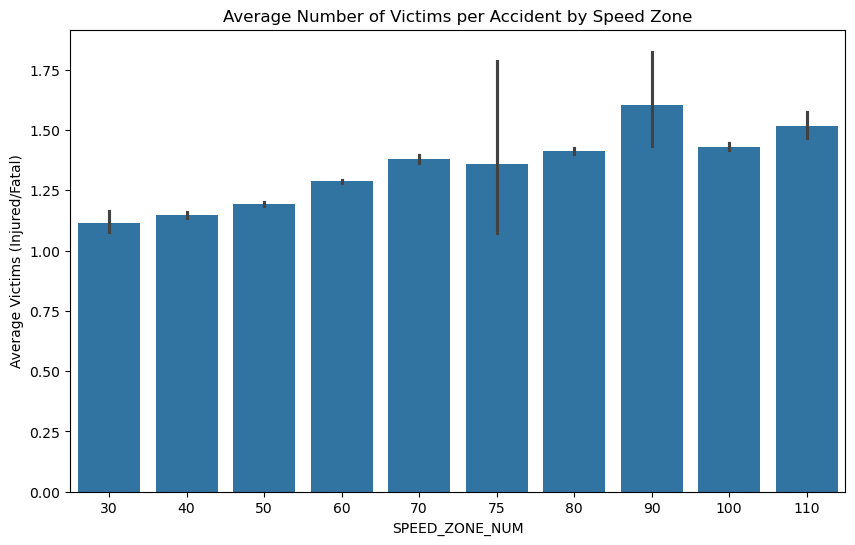

In [ ]:
# Code goes after this line by adding cells ddd
# 1. Filter for the two specific categories requested
severity_df = df[df['SEVERITY'].isin(['Serious injury accident', 'Other injury accident'])]

# 2. Distribution Plot
plt.figure(figsize=(10, 6))
sns.kdeplot(data=severity_df, x='SPEED_ZONE_NUM', hue='SEVERITY', fill=True, common_norm=False)
plt.title('Distribution of Speed Zones: Serious vs. Other Injury')
plt.xlabel('Speed Zone (km/hr)')
plt.ylabel('Density')
plt.show()

# 3. Relationship: Speed vs Total Victims (INJ_OR_FATAL)
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='SPEED_ZONE_NUM', y='INJ_OR_FATAL', estimator=np.mean)
plt.title('Average Number of Victims per Accident by Speed Zone')
plt.ylabel('Average Victims (Injured/Fatal)')
plt.show()

## Task 2.3 

C:\Users\tommy\AppData\Local\Temp\ipykernel_39552\100730814.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top5, x='LGA_NAME', y='SPEED_ZONE_NUM', palette="Set2")


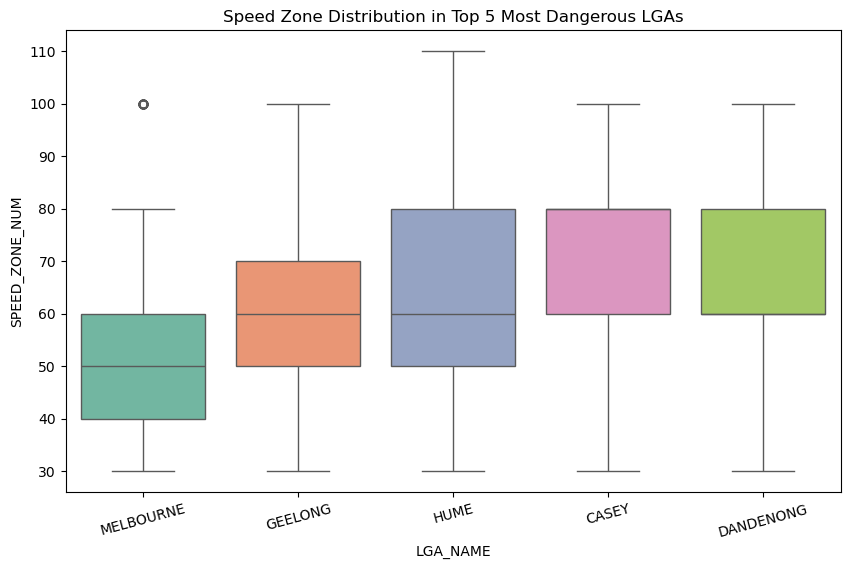

In [17]:
# Code goes after this line by adding cells
# 1. Identify the top 5 LGAs by total accident count
top_5_lgas = df['LGA_NAME'].value_counts().nlargest(5).index
df_top5 = df[df['LGA_NAME'].isin(top_5_lgas)]

# 2. Compare Speed Zone Distribution (Risk Factor 1)
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_top5, x='LGA_NAME', y='SPEED_ZONE_NUM', palette="Set2")
plt.title('Speed Zone Distribution in Top 5 Most Dangerous LGAs')
plt.xticks(rotation=15)
plt.show()
